In [1]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [2]:
# drive mount
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Import

In [8]:
import torchvision
from torchvision.transforms import v2
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F

Hyperparemeter

In [4]:
batch_size = 64
learning_rate = 1e-3
epochs = 20

Dataset

In [5]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale = True),
    # 2 pixel zero padding is used in the paper.
    v2.Pad(2),
    # normalization with range [-0.1, 1.175] is used in the paper.
    v2.Lambda(lambda x: x * 1.275 - 0.1)
])

path2data = "data"

training_data = torchvision.datasets.MNIST(
    root = path2data,
    train = True,
    download = True,
    transform = transform
)

test_data = torchvision.datasets.MNIST(
    root = path2data,
    train = False,
    download = True,
    transform = transform
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 495kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.56MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.75MB/s]


Image shape: torch.Size([1, 32, 32])
minimum: -0.100000, maximum: 1.175000
Label: 5


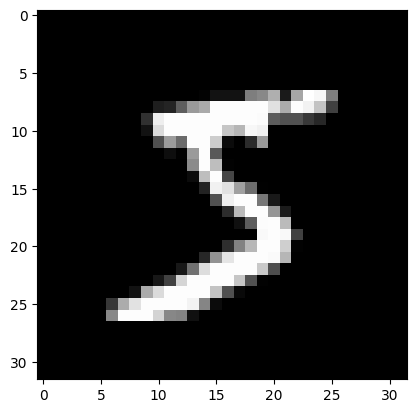

In [6]:
img, label = training_data[0]
print(f"Image shape: {img.shape}")
print(f"minimum: {img.min().item():>5f}, maximum: {img.max().item():>5f}")
print(f"Label: {label}")

img = img.squeeze()
plt.imshow(img, cmap = "gray")
plt.show()

Dataloader

In [7]:
train_dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
test_dataloader  = DataLoader(test_data,     batch_size=batch_size, shuffle=False)


Custom Layer

In [12]:
# Activation function used in the paper
class ScaledTanh(nn.Module):
    def forward(self, x):
        # 1.7159 is indicated in the paper <Gradient-based learning applied to document recognition>
        # 1.7159 and 2/3 are indicated in the paper <Efficient BackProp> which also published by Yann LeCun.
        return 1.7159 * torch.tanh(2/3 * x)
    
# Subsampling layer used in the paper
class Subsampling(nn.Module):
    def __init__(self, num_maps):
        super().__init__()
        self.coeff = nn.Parameter(torch.full((num_maps,), 0.25))
        self.bias = nn.Parameter(torch.zeros(num_maps))
        self.act = ScaledTanh()

    def forward(self, x):   # x: (N, C, H, W)
        s = F.avg_pool2d(x,2) * 4
        s = s * self.coeff.view(1,-1,1,1) + self.bias.view(1,-1,1,1)
        return self.act(s)
    
# C3 Layer used in the paper
C3_CONNECTIONS = [
    [0,1,2], [1,2,3], [2,3,4], [3,4,5], [0,4,5], [0,1,5],            # 3개 입력
    [0,1,2,3], [1,2,3,4], [2,3,4,5], [0,3,4,5], [0,1,4,5], [0,1,2,5],# 4개 입력(연속)
    [0,1,3,4], [1,2,4,5], [0,2,3,5],                                 # 4개 입력(비연속)
    [0,1,2,3,4,5],                                                   # 전부
]

class C3(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(6, 16, kernel_size=5)     # 일단 완전 연결 conv
        mask = torch.zeros(16, 6, 1, 1)                 # 연결 마스크
        for out_map, in_maps in enumerate(C3_CONNECTIONS):
            for in_map in in_maps:
                mask[out_map, in_map] = 1.0
        self.register_buffer("mask", mask)              # 학습X, .to(device) 따라감

    def forward(self, x):
        # 연결 안 된 입력의 weight를 0으로 마스킹해서 conv
        return F.conv2d(x, self.conv.weight * self.mask, self.conv.bias)

Model

In [14]:
class LeNet5(nn.Module):
    def __init__(self):
        super().__init__()
        self.C1 = nn.Conv2d(1, 6, kernel_size = 5)
        self.S2 = Subsampling(6)
        self.C3 = C3()
        self.S4 = Subsampling(16)
        self.C5 = nn.Conv2d(16, 120, kernel_size = 5)
        self.F6 = nn.Linear(120, 84)
        self.out = nn.Linear(84, 10)
        self.act = ScaledTanh()
    
    def forward(self, x):
        x = self.act(self.C1(x))
        x = self.S2(x)
        x = self.act(self.C3(x))
        x = self.S4(x)
        x = self.act(self.C5(x))
        x = torch.flatten(x, 1)
        x = self.act(self.F6(x)) 
        logits = self.out(x)          
        return logits

In [22]:
# Model output check

model = LeNet5().to(device)

from torchinfo import summary
summary(model, input_size = (1,32,32))

Layer (type:depth-idx)                   Output Shape              Param #
LeNet5                                   [1, 10]                   --
├─Conv2d: 1-1                            [6, 28, 28]               156
├─ScaledTanh: 1-2                        [6, 28, 28]               --
├─Subsampling: 1-3                       [1, 6, 14, 14]            12
│    └─ScaledTanh: 2-1                   [1, 6, 14, 14]            --
├─C3: 1-4                                [1, 16, 10, 10]           2,416
├─ScaledTanh: 1-5                        [1, 16, 10, 10]           --
├─Subsampling: 1-6                       [1, 16, 5, 5]             32
│    └─ScaledTanh: 2-2                   [1, 16, 5, 5]             --
├─Conv2d: 1-7                            [1, 120, 1, 1]            48,120
├─ScaledTanh: 1-8                        [1, 120, 1, 1]            --
├─Linear: 1-9                            [1, 84]                   10,164
├─ScaledTanh: 1-10                       [1, 84]                   --
├─L

Loss + Optimizier

In [23]:
model = LeNet5().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)

train_loop / test_loop

In [24]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)  
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

def test_loop(dataloader, model, loss_fn):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")


Epoch Loop

In [25]:
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loop(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.303272  [   64/60000]
loss: 0.577630  [ 6464/60000]
loss: 0.355946  [12864/60000]
loss: 0.388393  [19264/60000]
loss: 0.323144  [25664/60000]
loss: 0.230714  [32064/60000]
loss: 0.281537  [38464/60000]
loss: 0.105734  [44864/60000]
loss: 0.131884  [51264/60000]
loss: 0.044077  [57664/60000]
Test Error: 
 Accuracy: 96.5%, Avg loss: 0.112217 

Epoch 2
-------------------------------
loss: 0.066923  [   64/60000]
loss: 0.068857  [ 6464/60000]
loss: 0.014588  [12864/60000]
loss: 0.087765  [19264/60000]
loss: 0.125240  [25664/60000]
loss: 0.035151  [32064/60000]
loss: 0.022482  [38464/60000]
loss: 0.021269  [44864/60000]
loss: 0.048405  [51264/60000]
loss: 0.055742  [57664/60000]
Test Error: 
 Accuracy: 97.9%, Avg loss: 0.064698 

Epoch 3
-------------------------------
loss: 0.120767  [   64/60000]
loss: 0.082817  [ 6464/60000]
loss: 0.029969  [12864/60000]
loss: 0.113384  [19264/60000]
loss: 0.123253  [25664/60000]
loss: 0.010670  [32064/600